In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_excel('1Vlna.xlsx')
df2 = pd.read_excel('2Vlna.xlsx')
df3 = pd.read_excel('3Vlna.xlsx')
df4 = pd.read_excel('4Vlna.xlsx')

df1['vlna'] = 1
df2['vlna'] = 2
df3['vlna'] = 3
df4['vlna'] = 4

df_joined = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [3]:
df_joined = df_joined.dropna(subset=['Závažnosť priebehu ochorenia'])

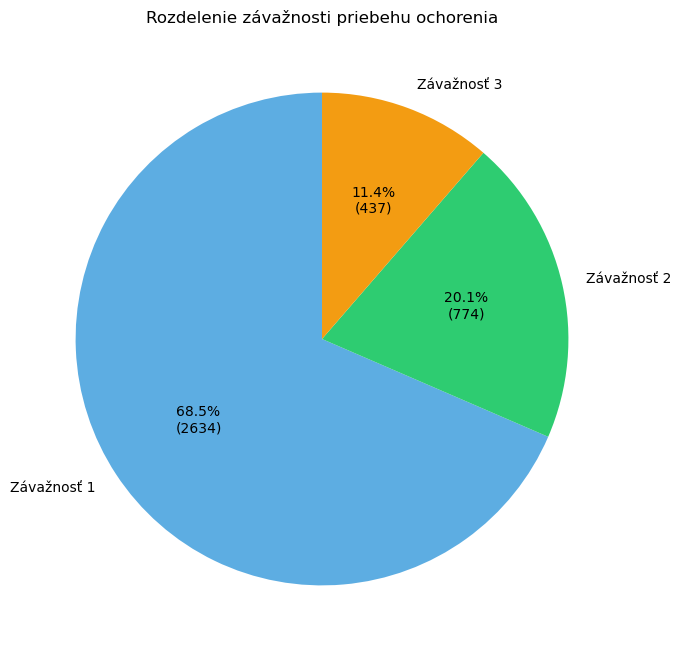

In [4]:
plt.figure(figsize=(8, 8))
colors = ['#5DADE2', '#2ecc71', '#f39c12']

counts = df_joined['Závažnosť priebehu ochorenia'].value_counts()
counts.index = ['Závažnosť ' + str(int(x)) for x in counts.index]

counts.plot.pie(
    autopct=lambda p: '{:.1f}%\n({:.0f})'.format(p, p * sum(counts) / 100),
    startangle=90, 
    colors=colors
)
plt.title('Rozdelenie závažnosti priebehu ochorenia')
plt.ylabel('')
plt.show()

In [5]:
df = df_joined[[
    
    'Pohlavie', 'Vek', 'vlna', 'Liečba', 'Závažnosť priebehu ochorenia', 'Hypertenzia', 'Diabetes mellitus', 'Kardiovaskulárne ochorenia', 'Chronické respiračné ochorenia', 'Renálne ochorenia', 'Pečeňové ochorenia', 'Onkologické ochorenia',
         
    'MD652 | FABIFLU TABLETS', 'MD656 IV-BECT 6MG (ivermectin)', '5042D | VEKLURY', '9547D | PAXLOVID', 'LAGEVRIO', 
         
    '00584 | PYRIDOXIN LÉČIVA INJ', '24836 | ACIDUM ASCORBICUM BBP', '89145 | VITAMIN C-INJEKTOPAS', '24814 | CALCIFEROL BBP 7,5 MG/ML', '92973 ALPHA D3', '00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK', '00449 | EREVIT 300 MG/ML', 
         
    '02963 | PREDNISON 20 LÉČIVA', '00269 | PREDNISON 5 LÉČIVA', '84090 | DEXAMED 6', '1275C | DEXAMETAZÓN KRKA', 'MD661 BIODEXONE-DEXAMETHASONE', '2410B HYDROCORTISONE', '3242C | OLUMIANT 4 MG', 'Anakinra', 'RoActemra', 
    
    '34045 | POLYOXIDONIUM 6 MG', '87299 | IMUNOR', '56930 IMMODIN', 'Isoprinosine, ', '3879d INOMED', 
    
    '35715 Azithromycin', '45954 Ceftriaxon', '0471B MOLOXIN', '9819A MOXIFLOXACIN', '58730 CIPROFLOXACIN KABI 200', '58746 CIPROFLOXACINKABI 400', 
    
    '05044 OZZION', '4147C OMEMYL', '89662 NOLPAZA', '39397 PANTOPRAZOL', 
    
    '94918 AMBROBENE', '24859 PENTOXYPHILLINUM', '8893 ACC INJEKT', '24949 CODEIN ', '26846 OXANTIL', 
    
    'FRAXIPARIN', 'CLEXANE', 'FRAGMIN', 
    
    'ASPIRIN', 'ANOPYRIN'
    
    ]]

# Toto je vyber podstatnych informacii z datasetu - demograficke udaje, informacia o covidovej vlne pocas ktorej bol pacient lieceny, zdravotny stav, komorbidity a podane lieky

# To, ci je pritomna komorbidita, resp. ci bol podany liek je vyjadrene binarnymi hodnotami TRUE/FALSE

In [6]:
# NASLEDUJE ZOSKUPENIE LIEKOV DO SKUPIN PODLA POKYNOV LEKAROV

In [7]:
target_col = '24836 | ACIDUM ASCORBICUM BBP'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Vitamin C", 
    value=(df['24836 | ACIDUM ASCORBICUM BBP'] | df['89145 | VITAMIN C-INJEKTOPAS'])
)

cols_to_drop = [
    '24836 | ACIDUM ASCORBICUM BBP',
    '89145 | VITAMIN C-INJEKTOPAS'
]

df = df.drop(columns=cols_to_drop)

In [8]:
target_col = '24814 | CALCIFEROL BBP 7,5 MG/ML'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Vitamin D", 
    value=(df['24814 | CALCIFEROL BBP 7,5 MG/ML'] | df['92973 ALPHA D3'])
)

cols_to_drop = [
    '24814 | CALCIFEROL BBP 7,5 MG/ML',
    '92973 ALPHA D3'
]

df = df.drop(columns=cols_to_drop)

In [9]:
target_col = '02963 | PREDNISON 20 LÉČIVA'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Prednison", 
    value=(df['02963 | PREDNISON 20 LÉČIVA'] | df['00269 | PREDNISON 5 LÉČIVA'])
)

cols_to_drop = [
    '02963 | PREDNISON 20 LÉČIVA',
    '00269 | PREDNISON 5 LÉČIVA'
]

df = df.drop(columns=cols_to_drop)

In [10]:
target_col = '84090 | DEXAMED 6'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Dexametazon", 
    value=(df['84090 | DEXAMED 6'] | df['1275C | DEXAMETAZÓN KRKA'] | df['MD661 BIODEXONE-DEXAMETHASONE'])
)

cols_to_drop = [
    '84090 | DEXAMED 6',
    '1275C | DEXAMETAZÓN KRKA',
    'MD661 BIODEXONE-DEXAMETHASONE'
]

df = df.drop(columns=cols_to_drop)

In [11]:
target_col = 'Anakinra'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,
    column='Kineret',
    value=df['Liečba'].str.contains(
        'kineret',
        case=False,
        na=False
    )
)

cols_to_drop = [
    'Anakinra'
]

df = df.drop(columns=cols_to_drop)

In [12]:
target_col = 'Isoprinosine, '
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Isoprinosine/INOMED", 
    value=(df['Isoprinosine, '] | df['3879d INOMED'])
)

cols_to_drop = [
    'Isoprinosine, ',
    '3879d INOMED'
]

df = df.drop(columns=cols_to_drop)

In [13]:
target_col = '0471B MOLOXIN'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Moxifloxacin", 
    value=(df['0471B MOLOXIN'] | df['9819A MOXIFLOXACIN'])
)

cols_to_drop = [
    '0471B MOLOXIN',
    '9819A MOXIFLOXACIN'
]

df = df.drop(columns=cols_to_drop)

In [14]:
target_col = '58730 CIPROFLOXACIN KABI 200'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Ciprofloxacin", 
    value=(df['58730 CIPROFLOXACIN KABI 200'] | df['58746 CIPROFLOXACINKABI 400'])
)

cols_to_drop = [
    '58730 CIPROFLOXACIN KABI 200',
    '58746 CIPROFLOXACINKABI 400'
]

df = df.drop(columns=cols_to_drop)

In [15]:
target_col = '05044 OZZION'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="PPI", 
    value=(df['05044 OZZION'] | df['4147C OMEMYL'] | df['89662 NOLPAZA'] | df['39397 PANTOPRAZOL'])
)

cols_to_drop = [
    '05044 OZZION',
    '4147C OMEMYL',
    '89662 NOLPAZA', 
    '39397 PANTOPRAZOL'
]

df = df.drop(columns=cols_to_drop)

In [16]:
target_col = 'FRAXIPARIN'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Antikoagulancia", 
    value=(df['FRAXIPARIN'] | df['CLEXANE'] | df['FRAGMIN'])
)

cols_to_drop = [
    'FRAXIPARIN',
    'CLEXANE',
    'FRAGMIN'
]

df = df.drop(columns=cols_to_drop)

In [17]:
target_col = 'ASPIRIN'
loc = df.columns.get_loc(target_col)

df.insert(
    loc=loc,                
    column="Antiagregacne", 
    value=(df['ASPIRIN'] | df['ANOPYRIN'])
)

cols_to_drop = [
    'ASPIRIN',
    'ANOPYRIN'
]

df = df.drop(columns=cols_to_drop)

In [18]:
df = df.drop(columns=['Liečba'])

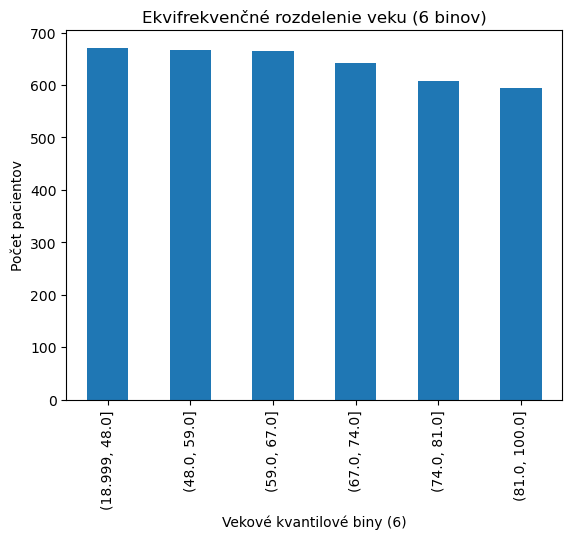

In [19]:
# vytvorenie ekvifrekvenčných binov
df["vek_q6"] = pd.qcut(df["Vek"], q=6)  # kategórie podľa kvantilov

# spočítanie počtov v jednotlivých binom
counts = df["vek_q6"].value_counts().sort_index()

counts.plot(kind="bar")
plt.xlabel("Vekové kvantilové biny (6)")
plt.ylabel("Počet pacientov")
plt.title("Ekvifrekvenčné rozdelenie veku (6 binov)")
plt.show()

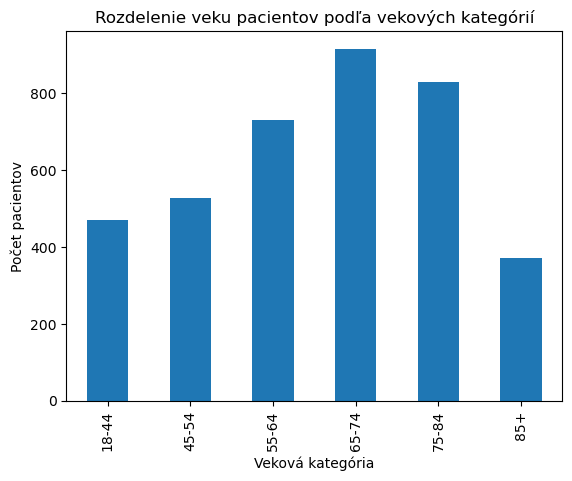

In [20]:
bins = [18, 45, 55, 65, 75, 85, 120] 
labels = [
    "18-44",
    "45-54",
    "55-64",
    "65-74",
    "75-84",
    "85+"
]

df["vek_kategoria"] = pd.cut(df["Vek"], bins=bins, right=False, labels=labels)

# histogram (bar plot) podľa kategórií
counts = df["vek_kategoria"].value_counts().sort_index()

counts.plot(kind="bar")
plt.xlabel("Veková kategória")
plt.ylabel("Počet pacientov")
plt.title("Rozdelenie veku pacientov podľa vekových kategórií")
plt.show()

In [21]:
target_col = 'Vek'
loc = df.columns.get_loc(target_col)

bins = [18, 45, 55, 65, 75, 85, 120]
labels = ["18-44", "45-54", "55-64", "65-74", "75-84", "85+"]

df.insert(
    loc=loc,                
    column="Vek_kat", 
    value=pd.cut(df["Vek"], bins=bins, right=False, labels=labels)
)

In [22]:
df = df.drop(columns=['Vek','vek_kategoria','vek_q6'])

In [24]:
# Vygenerovanie excel tabulky

df.to_excel('Upraveny_dataset.xlsx', index=False)